In [2]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score

# 1. Membuat dataset sesuai kasus
data = {
    'Sampel': range(1, 11),
    'Aktual': ['Ya', 'Tidak', 'Ya', 'Tidak', 'Ya', 'Tidak', 'Ya', 'Tidak', 'Ya', 'Tidak'],
    'Prediksi': ['Ya', 'Tidak', 'Ya', 'Tidak', 'Tidak', 'Ya', 'Ya', 'Tidak', 'Ya', 'Tidak']
}

df = pd.DataFrame(data)

# 2. Menghitung Confusion Matrix
# Kita tentukan labels=['Ya', 'Tidak'] agar urutan matrixnya (TP, FN, FP, TN)
y_true = df['Aktual']
y_pred = df['Prediksi']
labels = ['Ya', 'Tidak']

cm = confusion_matrix(y_true, y_pred, labels=labels)
tp, fn, fp, tn = cm.ravel()

# 3. Menghitung Metrik
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label='Ya')
recall = recall_score(y_true, y_pred, pos_label='Ya')

# 4. Menampilkan Hasil
print("--- Tabel Confusion Matrix ---")
print(f"TP: {tp} | FN: {fn}")
print(f"FP: {fp} | TN: {tn}")
print("-" * 30)
print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")

# Menampilkan laporan klasifikasi lengkap
print("\n--- Laporan Klasifikasi Lengkap ---")
print(classification_report(y_true, y_pred, target_names=labels))

--- Tabel Confusion Matrix ---
TP: 4 | FN: 1
FP: 1 | TN: 4
------------------------------
Accuracy  : 0.80
Precision : 0.80
Recall    : 0.80

--- Laporan Klasifikasi Lengkap ---
              precision    recall  f1-score   support

          Ya       0.80      0.80      0.80         5
       Tidak       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



--- Aturan Decision Tree (Text) ---
|--- Pengirim_Dikenal <= 0.50
|   |--- class: 1
|--- Pengirim_Dikenal >  0.50
|   |--- Promosi <= 0.50
|   |   |--- class: 0
|   |--- Promosi >  0.50
|   |   |--- class: 1



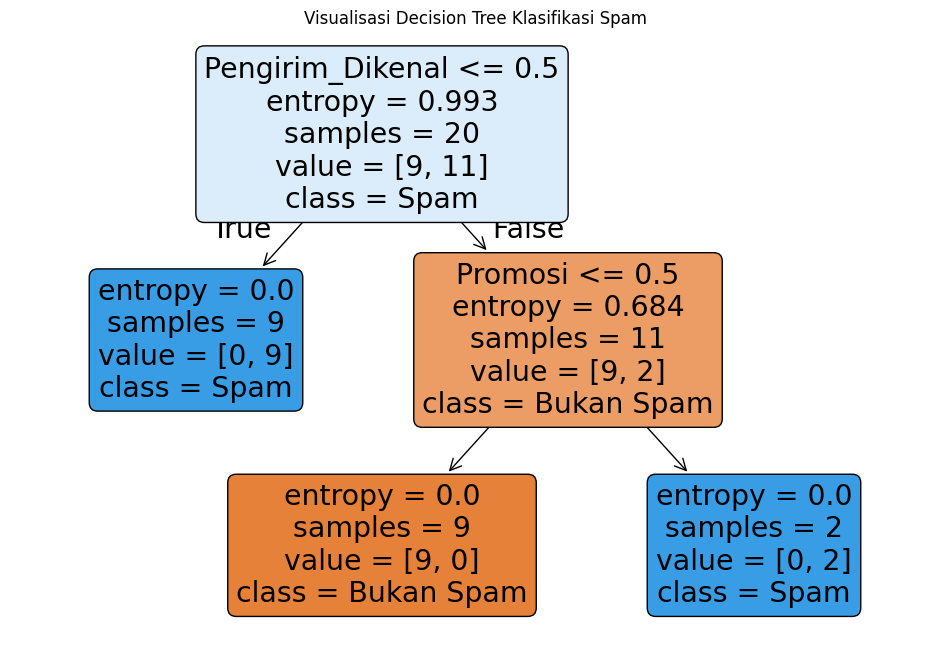

In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 1. Menyiapkan Data
data = {
    'Promosi': ['Ya', 'Tidak', 'Ya', 'Tidak', 'Tidak', 'Ya', 'Tidak', 'Tidak', 'Ya', 'Tidak', 
                'Tidak', 'Ya', 'Tidak', 'Tidak', 'Ya', 'Tidak', 'Ya', 'Tidak', 'Ya', 'Tidak'],
    'Link_Aneh': ['Ya', 'Tidak', 'Tidak', 'Tidak', 'Ya', 'Ya', 'Tidak', 'Tidak', 'Tidak', 'Ya', 
                  'Tidak', 'Ya', 'Ya', 'Tidak', 'Tidak', 'Tidak', 'Ya', 'Tidak', 'Tidak', 'Ya'],
    'Pengirim_Dikenal': ['Tidak', 'Ya', 'Tidak', 'Ya', 'Tidak', 'Tidak', 'Ya', 'Ya', 'Ya', 'Tidak', 
                         'Ya', 'Tidak', 'Tidak', 'Ya', 'Tidak', 'Ya', 'Tidak', 'Ya', 'Ya', 'Ya'],
    'Tanda_Seru': ['Ya', 'Tidak', 'Ya', 'Tidak', 'Tidak', 'Tidak', 'Tidak', 'Tidak', 'Ya', 'Ya', 
                   'Tidak', 'Ya', 'Tidak', 'Tidak', 'Tidak', 'Tidak', 'Tidak', 'Tidak', 'Ya', 'Tidak'],
    'Kelas': ['Spam', 'Bukan Spam', 'Spam', 'Bukan Spam', 'Spam', 'Spam', 'Bukan Spam', 'Bukan Spam', 'Spam', 'Spam',
              'Bukan Spam', 'Spam', 'Spam', 'Bukan Spam', 'Spam', 'Bukan Spam', 'Spam', 'Bukan Spam', 'Spam', 'Bukan Spam']
}

df = pd.DataFrame(data)

# 2. Encoding Data (Mengubah teks ke angka)
le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)

X = df_encoded.drop('Kelas', axis=1)
y = df_encoded['Kelas']
feature_names = X.columns
target_names = le.classes_

# 3. Membuat Model Decision Tree
# Menggunakan kriteria 'entropy' atau 'gini' untuk menentukan split
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# 4. Menampilkan Rules (Aturan)
tree_rules = export_text(clf, feature_names=list(feature_names))
print("--- Aturan Decision Tree (Text) ---")
print(tree_rules)

# 5. Visualisasi Pohon
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True, rounded=True)
plt.title("Visualisasi Decision Tree Klasifikasi Spam")
plt.show()

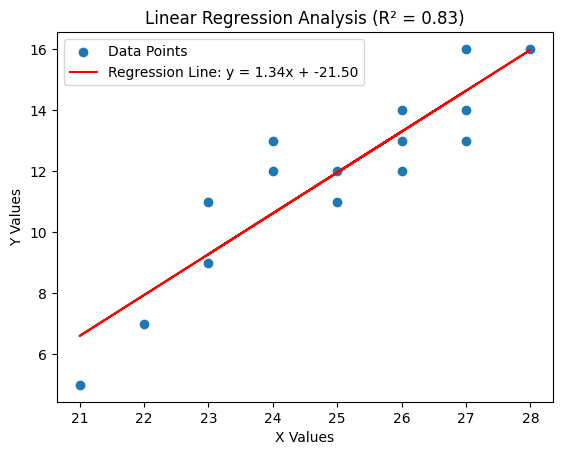

Slope: 1.3382
Intercept: -21.5000
Correlation Coefficient (r): 0.9090
R-squared: 0.8263


In [6]:
import matplotlib.pyplot as plt
from scipy import stats

# Data (as lists)
x = [27, 28, 25, 26, 24, 27, 23, 24, 23, 22, 21, 26, 25, 26, 27]
y = [13, 16, 12, 14, 12, 16, 9, 13, 11, 7, 5, 12, 11, 13, 14]

# 1. Perform linear regression
slope, intercept, r, p, std_err = stats.linregress(x, y)

# 2. Function to calculate predicted y values using the linear equation: y = mx + c
def predict_y(x_val):
    return slope * x_val + intercept

# 3. Create a list of predicted y values (the regression line)
regression_line = list(map(predict_y, x))

# 4. Create the scatter plot and regression line
plt.scatter(x, y, label='Data Points')
plt.plot(x, regression_line, color='red', label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f}')

# Add labels and a title
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.title(f'Linear Regression Analysis (R² = {r**2:.2f})')
plt.legend()
plt.show()

# Print statistical summary
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Correlation Coefficient (r): {r:.4f}")
print(f"R-squared: {r**2:.4f}")